# Setup & Imports

In [3]:
import pandas as pd

import matplotlib.pyplot as plt

import json

from pathlib import Path

# Load Data

In [ ]:
BASE_DIR = Path("S:/Zulassungskarten_Data")

metadata = []

for json_path in BASE_DIR.rglob("*.json"):
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

            data["_source_folder"] = json_path.parent.name
            data["_file_name"] = json_path.name

            metadata.append(data)

    except (json.JSONDecodeError, IOError) as e:
        print(f"Fehler beim Lesen von {json_path}: {e}")

df = pd.DataFrame(metadata)
df

# Data Cleaning

In [ ]:
# convert string to datetime
df['Prüfdatum'] = pd.to_datetime(df['Prüfdatum'], errors='coerce')

# extract year from Datetime and save in extra column
df['Jahr'] = df['Prüfdatum'].dt.year.astype('Int64')


# convert Prüfnummer to number
df['Prüfnummer'] = pd.to_numeric(df['Prüfnummer'], errors='coerce')

# sort by Prüfnummer
df = df.sort_values(by='Prüfnummer')

df

C:\Users\maris\AppData\Local\Temp\ipykernel_380\2689736599.py:2: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Prüfdatum'] = pd.to_datetime(df['Prüfdatum'], errors='coerce')


,Titel_und_Signatur,Bemerkung,Prüfnummer,Prüfdatum,Antragsteller,Produktion,Land,Filmart,Stumm-/Tonfilm,Länge (in Meter),Entscheidung,Unterlagenart,Benutzungsort,_source_folder,_file_name,Vorführungsbeschränkung,Ort des Prüfdatums,Jahr
0,R 9346-I/1\nDie Wölfin.\n1920 - 1945,nach Kürzung 1480 m,2.0,1920-06-24,"Solar-Film-Ges., Berlin","Solar-Film-Ges., Berlin",Deutschland,Puppenfilm,Stummfilm,1485,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_1,R 9346-I_1.json,NaN,NaN,1920
7198,R 9346-I/2\nDie Spieler\n1920 - 1945,NaN,7.0,1920-06-25,"Asslan-Film Continental, Berlin","Asslan-Film Continental, Berlin",Deutschland,Spielfilm,Stummfilm,2379,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_2,R 9346-I_2.json,NaN,NaN,1920
12260,R 9346-I/3\nSowas kommt von Sowas\n1920 - 1945,NaN,9.0,1920-06-24,"Karfiol-Film, Berlin","Karfiol-Film, Berlin",Deutschland,Spielfilm,Stummfilm,505,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_3,R 9346-I_3.json,NaN,NaN,1920
14575,R 9346-I/4\nDer Gefangene. (Sklaven des XX. Ja...,LF260322: Durch Blut und Eisen,11.0,1920-07-09,"Kowo Gesellschaft, Berlin","Kowo Gesellschaft, Berlin",Deutschland,Spielfilm,Stummfilm,1833,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_4,R 9346-I_4.json,NaN,NaN,1920
15679,R 9346-I/5\nDie entfesselte Menschheit\n1920 -...,NaN,20.0,1920-06-29,"Nivo-Film-Comp. GmbH, Berlin","Nivo-Film-Comp. GmbH, Berlin",Deutschland,Spielfilm,Stummfilm,2453,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_5,R 9346-I_5.json,NaN,NaN,1920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13129,R 9346-I/34232\nTraum und Wirklichkeit.\n1920 ...,NaN,NaN,1941-09-03,"Universum-Film AG, Berlin","Universum-Film AG, Berlin",Deutschland,Werbefilm,Tonfilm,40,Jugendfrei,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_34232,R 9346-I_34232.json,NaN,NaN,1941
13275,R 9346-I/34364\nSeines Glückes Schmied.\n1920 ...,NaN,NaN,1941-10-21,"Boehner-Film, Fritz Boehner, Dresden","Boehner-Film, Fritz Boehner, Dresden",Deutschland,Werbefilm,Tonfilm,62,Jugendfrei,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_34364,R 9346-I_34364.json,NaN,NaN,1941
13348,R 9346-I/34430\nSeines Glückes Schmied.\n1920 ...,Schmaltonfilm,NaN,1941-11-13,"Boehner-Film, Fritz Boehner, Dresden","Boehner-Film, Fritz Boehner, Dresden",Deutschland,Werbefilm,Tonfilm,s:25,Jugendfrei,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_34430,R 9346-I_34430.json,NaN,NaN,1941
13799,R 9346-I/34839\nLappland. See Fluß Meer.\n1920...,Schmaltonfilm,NaN,1942-05-11,"Herta von Rautenfeld, verw. Krupski, Arolsen",Dipl.-Ing. Ottomar Krupski +,Deutschland,Kulturfilm,Stummfilm,334,Jugendfrei,Zulassungskarte,Berlin-Lichterfelde,R 9346-I_34839,R 9346-I_34839.json,NaN,NaN,1942


# Statistical Analysis

## Reconstruction lost Documents

In [ ]:
summary = df.groupby('Jahr').agg(
    Eintraege_im_DF=('Prüfnummer', 'count'),
    Anfangs_Prüfnummer=('Prüfnummer', 'min'),
    End_Prüfnummer=('Prüfnummer', 'max')
).reset_index()

summary['Theoretische_Dokumente'] = summary['End_Prüfnummer'] - summary['Anfangs_Prüfnummer'] + 1
summary['Differenz_Fehlend'] = summary['Theoretische_Dokumente'] - summary['Eintraege_im_DF']

summary = summary[['Jahr', 'Anfangs_Prüfnummer', 'End_Prüfnummer', 'Theoretische_Dokumente', 'Eintraege_im_DF', 'Differenz_Fehlend']]

print(summary.to_string(index=False))

 Jahr  Anfangs_Prüfnummer  End_Prüfnummer  Theoretische_Dokumente  Eintraege_im_DF  Differenz_Fehlend
 1920                 2.0          2731.0                  2730.0              186             2544.0
 1921                22.0         23557.0                 23536.0             2287            21249.0
 1922              2491.0          6882.0                  4392.0             1447             2945.0
 1923              2887.0          7986.0                  5100.0              805             4295.0
 1924              6912.0          9600.0                  2689.0             1192             1497.0
 1925              9601.0         12101.0                  2501.0             1751              750.0
 1926             11934.0         14622.0                  2689.0             1393             1296.0
 1927             14536.0         18894.0                  4359.0             2299             2060.0
 1928              7049.0         21299.0                 14251.0             2460

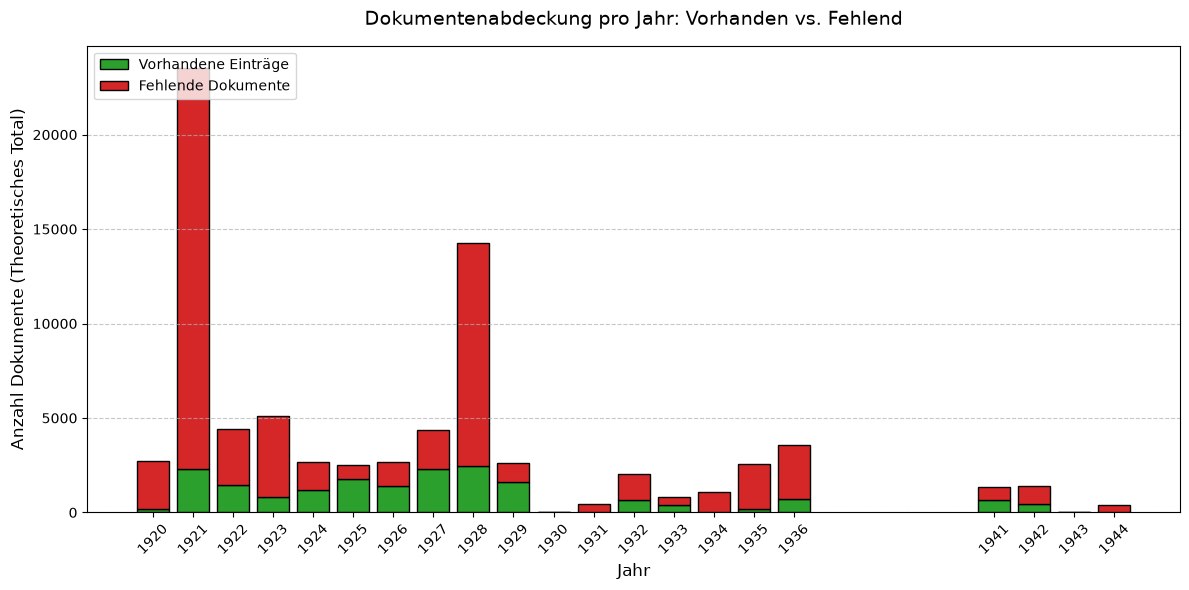

In [ ]:


# drop na
plot_df = summary.dropna(subset=['Jahr']).copy()

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    plot_df['Jahr'], 
    plot_df['Eintraege_im_DF'], 
    label='Vorhandene Einträge', 
    color='#2ca02c', # Grün für "OK"
    edgecolor='black'
)

ax.bar(
    plot_df['Jahr'], 
    plot_df['Differenz_Fehlend'], 
    bottom=plot_df['Eintraege_im_DF'], 
    label='Fehlende Dokumente', 
    color='#d62728', # Rot für "Fehlt"
    edgecolor='black'
)


ax.set_title('Dokumentenabdeckung pro Jahr: Vorhanden vs. Fehlend', fontsize=14, pad=15)
ax.set_xlabel('Jahr', fontsize=12)
ax.set_ylabel('Anzahl Dokumente (Theoretisches Total)', fontsize=12)

ax.set_xticks(plot_df['Jahr'])
ax.set_xticklabels(plot_df['Jahr'], rotation=45)

ax.grid(axis='y', linestyle='--', alpha=0.7)

ax.legend(loc='upper left')

plt.tight_layout()

plt.show()

## Decision 

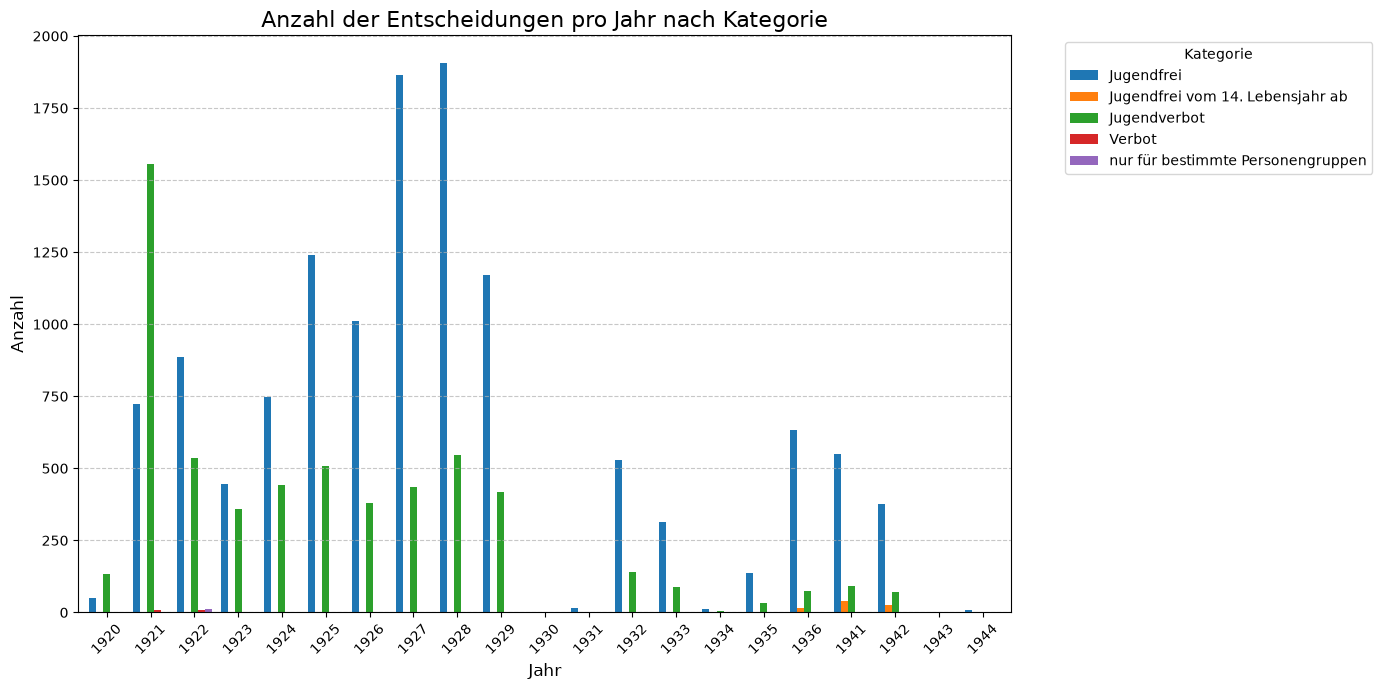

In [ ]:
df_grouped = df.groupby(['Jahr', 'Entscheidung']).size().unstack(fill_value=0)

ax = df_grouped.plot(kind='bar', figsize=(14, 7), width=0.8)

plt.title('Anzahl der Entscheidungen pro Jahr nach Kategorie', fontsize=16)
plt.xlabel('Jahr', fontsize=12)
plt.ylabel('Anzahl', fontsize=12)
plt.legend(title='Kategorie', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.7) 

plt.tight_layout()
plt.show()


## Filmtypes

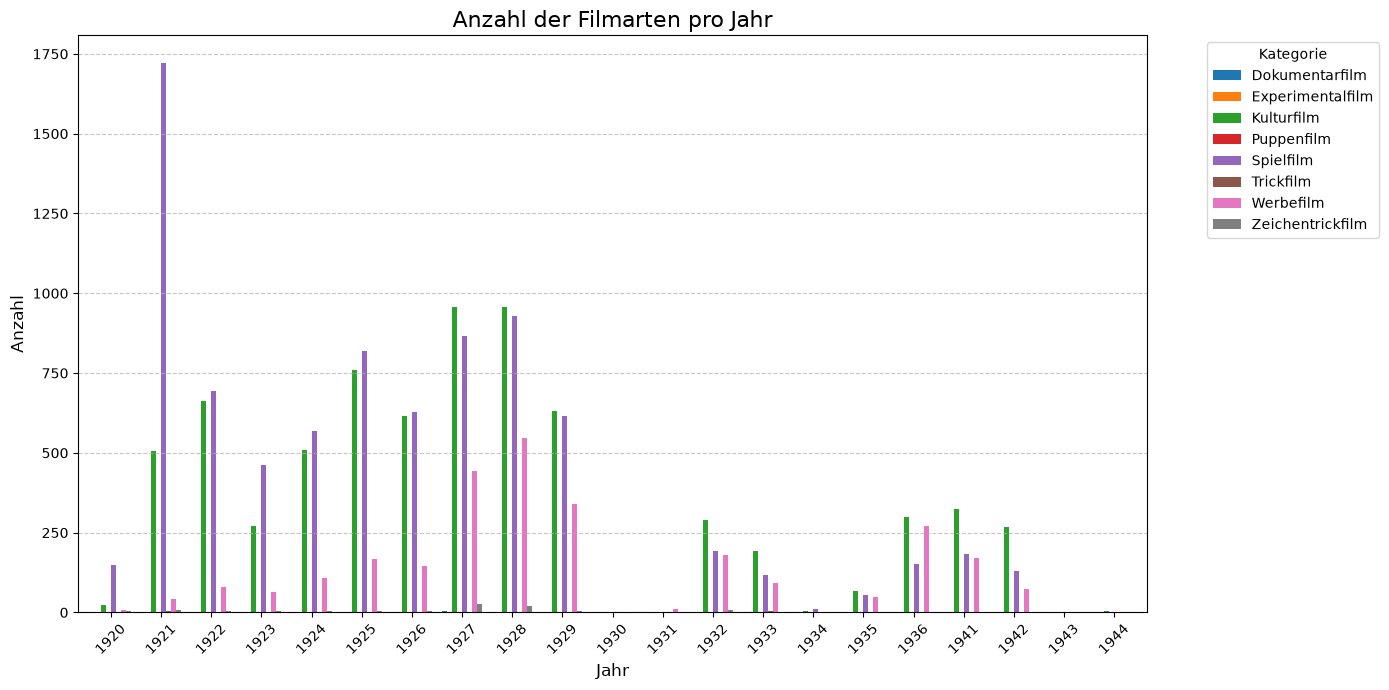

In [ ]:
df_grouped = df.groupby(['Jahr', 'Filmart']).size().unstack(fill_value=0)

ax = df_grouped.plot(kind='bar', figsize=(14, 7), width=0.8)

plt.title('Anzahl der Filmarten pro Jahr', fontsize=16)
plt.xlabel('Jahr', fontsize=12)
plt.ylabel('Anzahl', fontsize=12)
plt.legend(title='Kategorie', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.7) 

plt.tight_layout()
plt.show()


##

In [ ]:
# df_grouped = df.groupby(['Jahr', 'Produktion']).size().unstack(fill_value=0)

# ax = df_grouped.plot(kind='bar', figsize=(14, 7), width=0.8)

# plt.title('Anzahl der Filmarten pro Jahr', fontsize=16)
# plt.xlabel('Jahr', fontsize=12)
# plt.ylabel('Anzahl', fontsize=12)
# plt.legend(title='Kategorie', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.xticks(rotation=45) 
# plt.grid(axis='y', linestyle='--', alpha=0.7) 

# plt.tight_layout()
# plt.show()


In [ ]:
# df_grouped = df.groupby(['Jahr', 'Land']).size().unstack(fill_value=0)

# ax = df_grouped.plot(kind='bar', figsize=(14, 7), width=0.8)

# plt.title('Anzahl der Filmarten pro Jahr', fontsize=16)
# plt.xlabel('Jahr', fontsize=12)
# plt.ylabel('Anzahl', fontsize=12)
# plt.legend(title='Kategorie', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.xticks(rotation=45) 
# plt.grid(axis='y', linestyle='--', alpha=0.7) 

# plt.tight_layout()
# plt.show()
